## Import Required Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Dense, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report, roc_curve,auc)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display TensorFlow Version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# Data Loading

In [2]:
import tensorflow as tf

# Dataset Paths
train_dir = r"C:\building_crack_system\data_set\train"
val_dir   = r"C:\building_crack_system\data_set\Validation"
test_dir  = r"C:\building_crack_system\data_set\test"

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED
)

# Load Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

# Load Test Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

# Display Class Names
class_names = train_dataset.class_names
print("Class Names:", class_names)

# Display Dataset Information
print("\nTraining Batches :", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation Batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Testing Batches  :", tf.data.experimental.cardinality(test_dataset).numpy())

Found 40000 files belonging to 2 classes.
Found 40000 files belonging to 2 classes.
Found 40001 files belonging to 2 classes.
Class Names: ['crack', 'non_crack']

Training Batches : 1250
Validation Batches: 1250
Testing Batches  : 1251


# Save class names

In [3]:
class_names = train_dataset.class_names

print(class_names)

['crack', 'non_crack']


# Data Preprocessing (Resize & Normalize)

In [4]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# Image size
IMG_SIZE = (224, 224)

# Resize and Normalize Function
def preprocess(image, label):
    # Resize image
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixel values using ResNet50 preprocessing
    image = preprocess_input(image)

    return image, label

# Apply preprocessing to datasets
train_dataset = train_dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Optimize dataset performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


# Data Augmentation 

In [5]:
import tensorflow as tf

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2)
], name="data_augmentation")

# Apply augmentation only to training dataset
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Optimize dataset performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Data augmentation applied successfully.")

Data augmentation applied successfully.


# Random Image Visualization

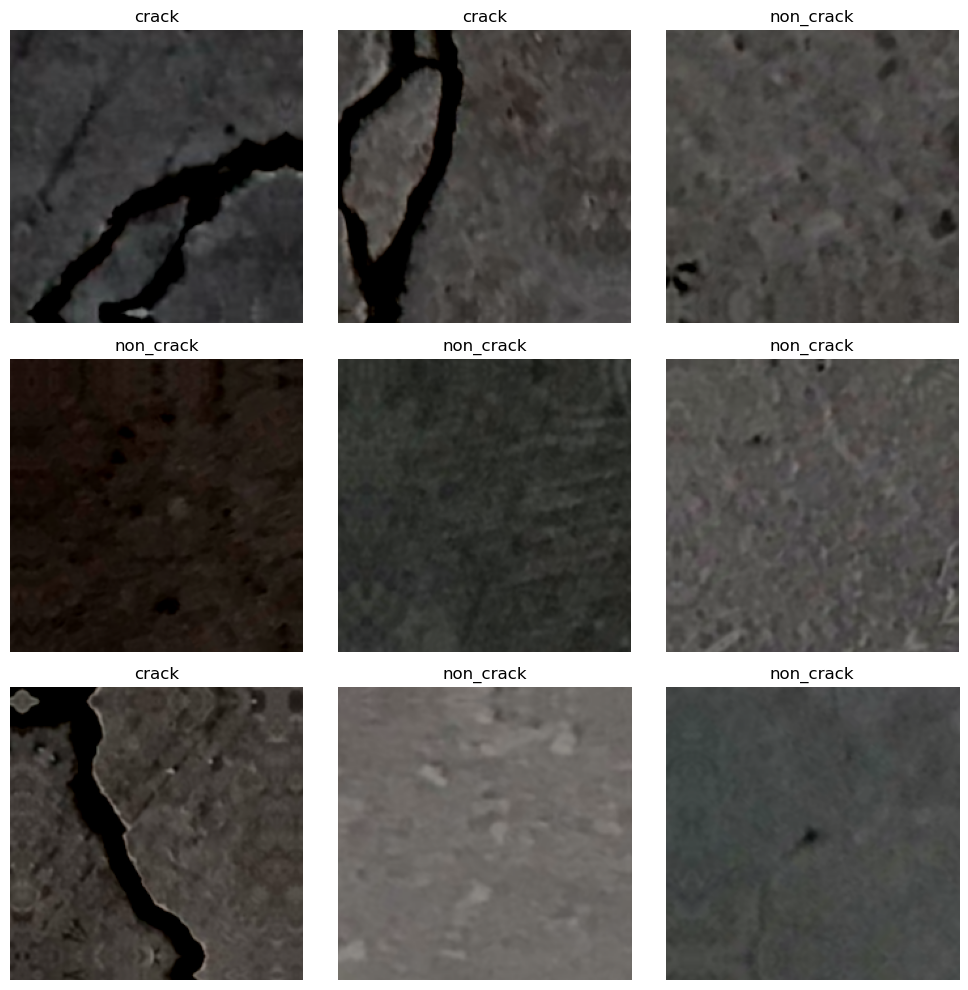

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

# ResNet50 Model

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

output = Dense(1, activation="sigmoid")(x)

# Final Model
resnet50_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="ResNet50_Crack_Detection"
)

# Model Summary
resnet50_model.summary()

Model: "ResNet50_Crack_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,727,105 (90.51 MB)

 Trainable params: 135,297 (528.50 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

# Compile Model

In [8]:
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train Model

In [10]:
history = resnet50_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3453s 3s/step - accuracy: 0.9812 - loss: 0.0523 - val_accuracy: 0.9974 - val_loss: 0.0085
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3436s 3s/step - accuracy: 0.9940 - loss: 0.0194 - val_accuracy: 0.9978 - val_loss: 0.0077
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3490s 3s/step - accuracy: 0.9949 - loss: 0.0157 - val_accuracy: 0.9977 - val_loss: 0.0069
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3446s 3s/step - accuracy: 0.9952 - loss: 0.0139 - val_accuracy: 0.9969 - val_loss: 0.0095
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3400s 3s/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9972 - val_loss: 0.0082


# Predict on Test Images

In [11]:
import numpy as np
import random

# Generate predictions
predictions = resnet50_model.predict(test_dataset)

# Convert probabilities to binary labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Extract true labels
y_true = np.concatenate([
    labels.numpy().astype(int).flatten()
    for _, labels in test_dataset
])

# Class names (0 = crack, 1 = non_crack)
class_names = ["crack", "non_crack"]

# Select 6 random images
random_indices = random.sample(range(len(y_true)), 6)

print("=" * 50)
print("Random Predictions")
print("=" * 50)

for idx in random_indices:

    actual = class_names[y_true[idx]]

    confidence = predictions[idx][0]

    if y_pred[idx] == 0:
        predicted = "crack"
        confidence = (1 - confidence) * 100
    else:
        predicted = "non_crack"
        confidence = confidence * 100

    print(f"Image Index : {idx}")
    print(f"Actual      : {actual}")
    print(f"Predicted   : {predicted}")
    print(f"Confidence  : {confidence:.2f}%")
    print("-" * 40)

1251/1251 ━━━━━━━━━━━━━━━━━━━━ 1626s 1s/step
Random Predictions
Image Index : 15002
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------
Image Index : 7748
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------
Image Index : 17074
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------
Image Index : 36376
Actual      : non_crack
Predicted   : non_crack
Confidence  : 100.00%
----------------------------------------
Image Index : 5001
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------
Image Index : 12759
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------


# Evaluation Metrics

1251/1251 ━━━━━━━━━━━━━━━━━━━━ 1654s 1s/step
ResNet50 Performance
Accuracy : 0.9972
Precision: 0.9952
Recall   : 0.9991
F1-Score : 0.9972

Classification Report

              precision    recall  f1-score   support

       crack       1.00      1.00      1.00     20001
   non_crack       1.00      1.00      1.00     20000

    accuracy                           1.00     40001
   macro avg       1.00      1.00      1.00     40001
weighted avg       1.00      1.00      1.00     40001



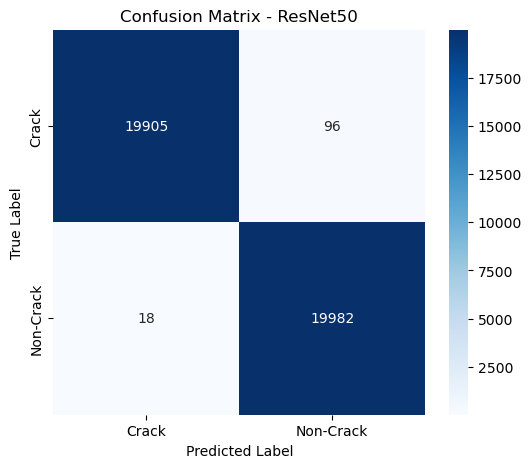

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Predict probabilities
y_prob = resnet50_model.predict(test_dataset)

# Convert probabilities to binary predictions
y_pred = (y_prob > 0.5).astype(int).flatten()

# Extract true labels
y_true = np.concatenate([
    labels.numpy().astype(int).flatten()
    for _, labels in test_dataset
])

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision
precision = precision_score(y_true, y_pred)

# Recall
recall = recall_score(y_true, y_pred)

# F1 Score
f1 = f1_score(y_true, y_pred)


# Print Metrics

print("=" * 50)
print("ResNet50 Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report
print("\nClassification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["crack", "non_crack"]
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Crack","Non-Crack"],
    yticklabels=["Crack","Non-Crack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# Save ResNet50 Model

In [14]:
import os

os.makedirs("models", exist_ok=True)

# Save ResNet50 Model
resnet50_model.save("models/resnet50_model.keras")

print("ResNet50 model saved successfully!")

ResNet50 model saved successfully!


# MobileNetV2 Model 

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

output = Dense(1, activation="sigmoid")(x)

# Output Layer
output = Dense(1,activation="sigmoid",name="prediction")(x)

# Final Model
mobilenetv2_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="MobileNetV2_Crack_Detection"
)

# Model Summary
mobilenetv2_model.summary()

Model: "MobileNetV2_Crack_Detection"

┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)    ┃ Output Shape ┃ Param # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2   │ (None, 224,  │       0 │ -             │
│ (InputLayer)    │ 224, 3)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ Conv1 (Conv2D)  │ (None, 112,  │     864 │ input_layer_… │
│                 │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ bn_Conv1        │ (None, 112,  │     128 │ Conv1[0][0]   │
│ (BatchNormaliz… │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ Conv1_relu      │ (None, 112,  │       0 │ bn_Conv1[0][… │
│ (ReLU)          │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ expanded_conv_… │ (None, 112,  │     288 │ Conv1_relu[0… │
│ (DepthwiseConv… │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ expanded_conv_… │ (None, 112,  │     128 │ expanded_con… │
│ (BatchNormaliz… │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ expanded_conv_… │ (None, 112,  │       0 │ expanded_con… │
│ (ReLU)          │ 112, 32)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ expanded_conv_… │ (None, 112,  │     512 │ expanded_con… │
│ (Conv2D)        │ 112, 16)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ expanded_conv_… │ (None, 112,  │      64 │ expanded_con… │
│ (BatchNormaliz… │ 112, 16)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_expand  │ (None, 112,  │   1,536 │ expanded_con… │
│ (Conv2D)        │ 112, 96)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_expand… │ (None, 112,  │     384 │ block_1_expa… │
│ (BatchNormaliz… │ 112, 96)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_expand… │ (None, 112,  │       0 │ block_1_expa… │
│ (ReLU)          │ 112, 96)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_pad     │ (None, 113,  │       0 │ block_1_expa… │
│ (ZeroPadding2D) │ 113, 96)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_depthw… │ (None, 56,   │     864 │ block_1_pad[… │
│ (DepthwiseConv… │ 56, 96)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_depthw… │ (None, 56,   │     384 │ block_1_dept… │
│ (BatchNormaliz… │ 56, 96)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_depthw… │ (None, 56,   │       0 │ block_1_dept… │
│ (ReLU)          │ 56, 96)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_project │ (None, 56,   │   2,304 │ block_1_dept… │
│ (Conv2D)        │ 56, 24)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_1_projec… │ (None, 56,   │      96 │ block_1_proj… │
│ (BatchNormaliz… │ 56, 24)      │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_2_expand  │ (None, 56,   │   3,456 │ block_1_proj… │
│ (Conv2D)        │ 56, 144)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_2_expand… │ (None, 56,   │     576 │ block_2_expa… │
│ (BatchNormaliz… │ 56, 144)     │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ block_2_expand… │ (None, 56,   │       0 │ block_2_expa… │
│ (ReLU)          │ 56, 144)     │         │               │
├─────────────────┼──────────────┼─

 Total params: 2,345,153 (8.95 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

# Compile the Model

In [16]:
from tensorflow.keras.optimizers import Adam

mobilenetv2_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✅ MobileNetV2 model compiled successfully!")

✅ MobileNetV2 model compiled successfully!


# Train the Model

In [18]:
history_mobilenet = mobilenetv2_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 864s 685ms/step - accuracy: 0.9807 - loss: 0.0581 - val_accuracy: 0.9884 - val_loss: 0.0389
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 924s 739ms/step - accuracy: 0.9914 - loss: 0.0295 - val_accuracy: 0.9887 - val_loss: 0.0383
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 918s 734ms/step - accuracy: 0.9924 - loss: 0.0244 - val_accuracy: 0.9906 - val_loss: 0.0305
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 904s 722ms/step - accuracy: 0.9923 - loss: 0.0252 - val_accuracy: 0.9901 - val_loss: 0.0312
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 910s 727ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accuracy: 0.9911 - val_loss: 0.0286


# Predict on Test Images

In [19]:
import numpy as np
import random

# Predict probabilities
predictions = mobilenetv2_model.predict(test_dataset)

# Convert probabilities to binary labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Extract true labels
y_true = np.concatenate([
    labels.numpy().astype(int).flatten()
    for _, labels in test_dataset
])

# Class names (0 = crack, 1 = non_crack)
class_names = ["crack", "non_crack"]

# Select 6 random images
random_indices = random.sample(range(len(y_true)), 6)

print("=" * 50)
print("Random Predictions")
print("=" * 50)

for idx in random_indices:

    actual = class_names[y_true[idx]]

    confidence = predictions[idx][0]

    if y_pred[idx] == 0:
        predicted = "crack"
        confidence = (1 - confidence) * 100
    else:
        predicted = "non_crack"
        confidence = confidence * 100

    print(f"Image Index : {idx}")
    print(f"Actual      : {actual}")
    print(f"Predicted   : {predicted}")
    print(f"Confidence  : {confidence:.2f}%")
    print("-" * 40)

1251/1251 ━━━━━━━━━━━━━━━━━━━━ 412s 328ms/step
Random Predictions
Image Index : 20361
Actual      : non_crack
Predicted   : non_crack
Confidence  : 99.60%
----------------------------------------
Image Index : 38828
Actual      : non_crack
Predicted   : non_crack
Confidence  : 99.69%
----------------------------------------
Image Index : 12342
Actual      : crack
Predicted   : crack
Confidence  : 100.00%
----------------------------------------
Image Index : 31699
Actual      : non_crack
Predicted   : non_crack
Confidence  : 99.94%
----------------------------------------
Image Index : 29267
Actual      : non_crack
Predicted   : non_crack
Confidence  : 99.96%
----------------------------------------
Image Index : 21964
Actual      : non_crack
Predicted   : non_crack
Confidence  : 99.86%
----------------------------------------


# Evaluation Metrics

1251/1251 ━━━━━━━━━━━━━━━━━━━━ 410s 327ms/step
MobileNetV2 Performance Evaluation
Accuracy : 0.9911
Precision: 0.9959
Recall   : 0.9861
F1-Score : 0.9910

Classification Report

              precision    recall  f1-score   support

       crack       0.99      1.00      0.99     20001
   non_crack       1.00      0.99      0.99     20000

    accuracy                           0.99     40001
   macro avg       0.99      0.99      0.99     40001
weighted avg       0.99      0.99      0.99     40001



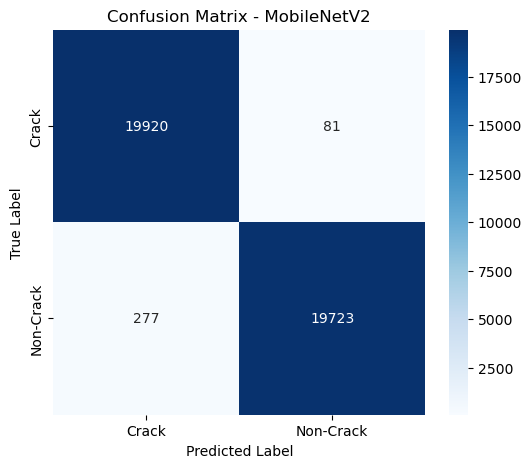

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Predict probabilities
y_prob = mobilenetv2_model.predict(test_dataset)

# Convert probabilities to binary predictions
y_pred = (y_prob > 0.5).astype(int).flatten()

# Extract true labels
y_true = np.concatenate([
    labels.numpy().astype(int).flatten()
    for _, labels in test_dataset
])

# Calculate Metrics

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("=" * 55)
print("MobileNetV2 Performance Evaluation")
print("=" * 55)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report

print("\nClassification Report\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=["crack", "non_crack"]
))

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Crack","Non-Crack"],
    yticklabels=["Crack","Non-Crack"]
)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Save Model

In [22]:
import os

os.makedirs("models", exist_ok=True)

# Save ResNet50 Model
mobilenetv2_model.save("models/mobilnetv2_model.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


# Crack Percentage


Image 1
Crack Area        : 8263 pixels²
Image Area        : 51529 pixels²
Crack Percentage  : 16.04%


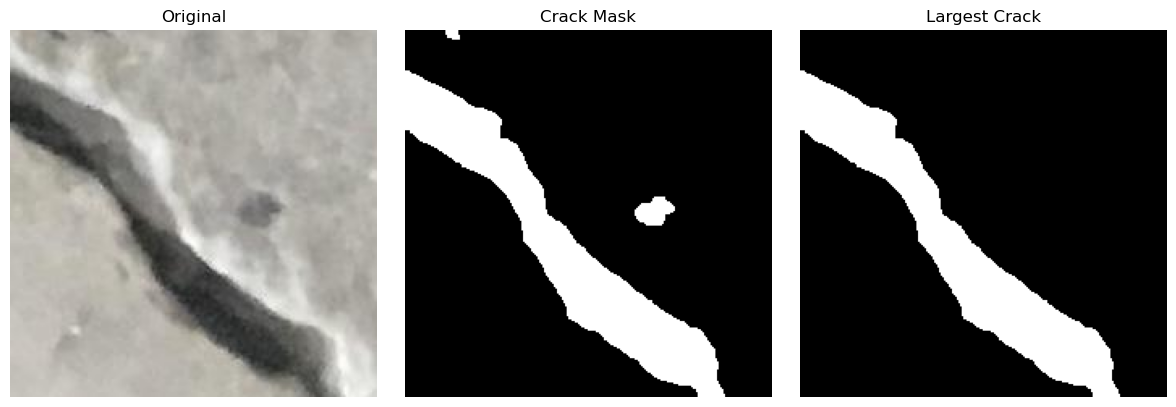


Image 2
Crack Area        : 1727 pixels²
Image Area        : 51529 pixels²
Crack Percentage  : 3.35%


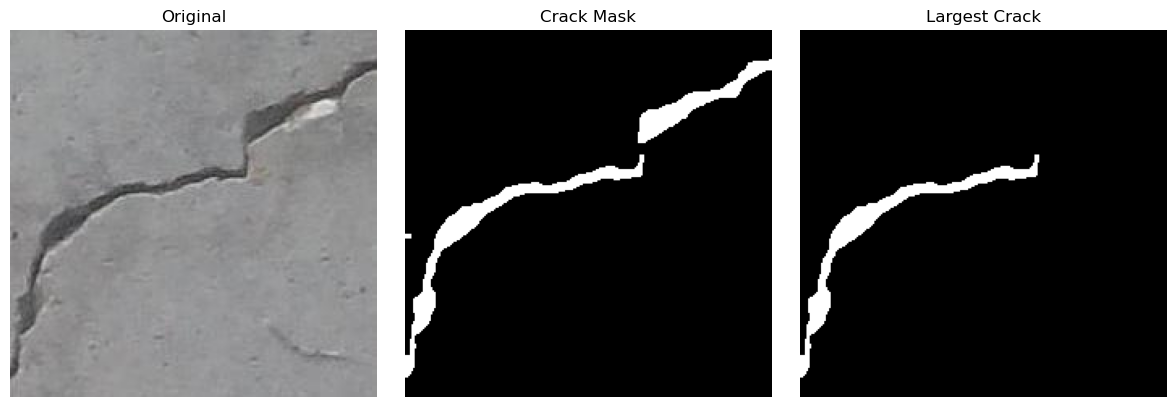


Image 3
Crack Area        : 5759 pixels²
Image Area        : 51529 pixels²
Crack Percentage  : 11.18%


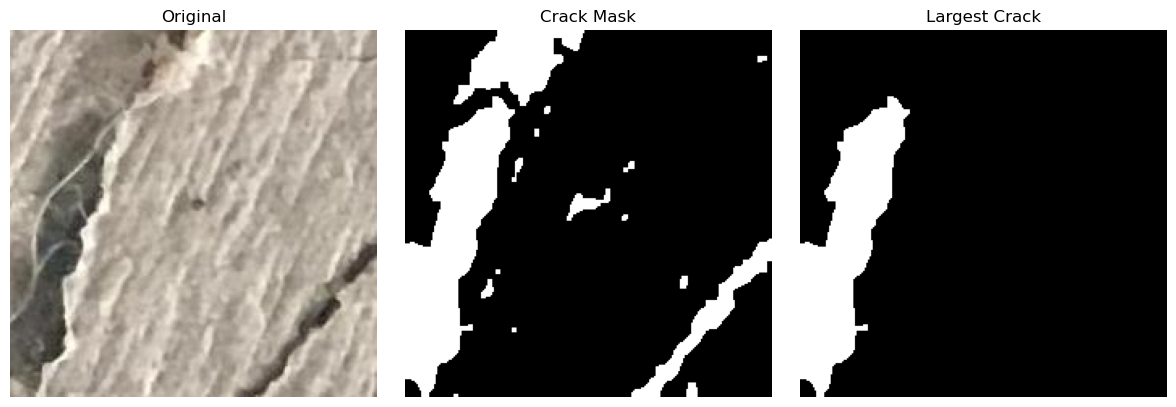

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

for idx, img_path in enumerate(random_images):

    # Read image
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to Gray
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Otsu Threshold
    _, binary = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological Filtering
    kernel = np.ones((3,3), np.uint8)

    opening = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    crack_mask = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Largest Crack Extraction

    contours, _ = cv2.findContours(
        crack_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest_mask = np.zeros_like(crack_mask)

    if len(contours) > 0:

        largest_contour = max(contours, key=cv2.contourArea)

        cv2.drawContours(
            largest_mask,
            [largest_contour],
            -1,
            255,
            thickness=cv2.FILLED
        )

    # Crack Area

    crack_area = cv2.countNonZero(largest_mask)

    total_area = largest_mask.shape[0] * largest_mask.shape[1]

    crack_percentage = (crack_area / total_area) * 100

    print(f"\nImage {idx+1}")
    print(f"Crack Area        : {crack_area:.0f} pixels²")
    print(f"Image Area        : {total_area:.0f} pixels²")
    print(f"Crack Percentage  : {crack_percentage:.2f}%")

    # Display

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(crack_mask, cmap="gray")
    plt.title("Crack Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(largest_mask, cmap="gray")
    plt.title("Largest Crack")
    plt.axis("off")

    plt.tight_layout()
    plt.show()